In [23]:
!pip install transformers torch pandas scikit-learn

In [1]:
import pandas as pd
df = pd.read_csv("customer_support_tickets.csv")
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [2]:
from transformers import pipeline
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
candidate_labels = [
    "Technical issue",
    "Billing inquiry",
    "Cancellation request",
    "Product inquiry",
    "Refund request"
]

In [4]:
ticket = "Payment failed but amount deducted from my bank account"

result = classifier(
    ticket,
    candidate_labels
)

print(result)

{'sequence': 'Payment failed but amount deducted from my bank account', 'labels': ['Billing Issue', 'Account Recovery', 'Subscription Problem', 'Refund Request', 'Technical Issue', 'Login Problem', 'Shipping Issue'], 'scores': [0.3069281280040741, 0.22377051413059235, 0.12247375398874283, 0.11642606556415558, 0.09311853349208832, 0.07701968401670456, 0.06026322767138481]}


In [5]:
top_3 = result["labels"][:3]

scores = result["scores"][:3]

for label, score in zip(top_3, scores):
    print(label, ":", round(score, 3))

Billing Issue : 0.307
Account Recovery : 0.224
Subscription Problem : 0.122


In [6]:
few_shot_prompt = """
Examples:

Ticket: Cannot reset my password
Tag: Account Recovery

Ticket: App crashes after update
Tag: Technical Issue

Ticket: Charged twice for same purchase
Tag: Billing Issue

Now classify:

Ticket: Payment failed but money deducted
"""

In [7]:
df = df.head(50)

In [13]:
tickets = df["Ticket Description"].tolist()

# Re-running classification with updated candidate_labels
results = classifier(
    tickets,
    candidate_labels,
    batch_size=8
)

predictions = []
for result in results:
    predictions.append(result["labels"][:3])

df["Top_3_Tags"] = predictions
display(df[["Ticket Description", "Ticket Type", "Top_3_Tags"]].head())

,Ticket Description,Ticket Type,Top_3_Tags
0,I'm having an issue with the {product_purchase...,Technical issue,"[Product inquiry, Billing inquiry, Technical i..."
1,I'm having an issue with the {product_purchase...,Technical issue,"[Product inquiry, Technical issue, Billing inq..."
2,I'm facing a problem with my {product_purchase...,Technical issue,"[Product inquiry, Billing inquiry, Technical i..."
3,I'm having an issue with the {product_purchase...,Billing inquiry,"[Product inquiry, Billing inquiry, Technical i..."
4,I'm having an issue with the {product_purchase...,Billing inquiry,"[Product inquiry, Billing inquiry, Technical i..."


In [9]:
df.to_csv("outputs.csv", index=False)

print("Results saved!")

Results saved!


In [15]:
from sklearn.metrics import accuracy_score

# Top-1 predicted label
y_pred_top1 = [result[0].strip().lower() for result in df["Top_3_Tags"]]

# Normalize ground truth
y_true = df["Ticket Type"].str.strip().str.lower().tolist()

# Calculate Top-1 Accuracy
top1_accuracy = accuracy_score(y_true, y_pred_top1)

# Calculate Top-3 Accuracy (checks if true label is anywhere in the top 3 list)
top3_hits = 0
for actual, pred_list in zip(y_true, df["Top_3_Tags"]):
    # Normalize prediction list for comparison
    normalized_preds = [p.strip().lower() for p in pred_list]
    if actual in normalized_preds:
        top3_hits += 1

top3_accuracy = top3_hits / len(y_true)

print(f"Zero-shot Top-1 Accuracy: {top1_accuracy:.2f}")
print(f"Zero-shot Top-3 Accuracy: {top3_accuracy:.2f}")

# Display detailed results
comparison_df = pd.DataFrame({
    'Actual': y_true,
    'Top Prediction': y_pred_top1,
    'In Top 3': [a in [p.strip().lower() for p in pl] for a, pl in zip(y_true, df["Top_3_Tags"])]
})
display(comparison_df.head(15))

Zero-shot Top-1 Accuracy: 0.22
Zero-shot Top-3 Accuracy: 0.64


,Actual,Top Prediction,In Top 3
0,technical issue,product inquiry,True
1,technical issue,product inquiry,True
2,technical issue,product inquiry,True
3,billing inquiry,product inquiry,True
4,billing inquiry,product inquiry,True
5,cancellation request,product inquiry,False
6,product inquiry,product inquiry,True
7,refund request,product inquiry,False
8,technical issue,product inquiry,True
9,refund request,product inquiry,False


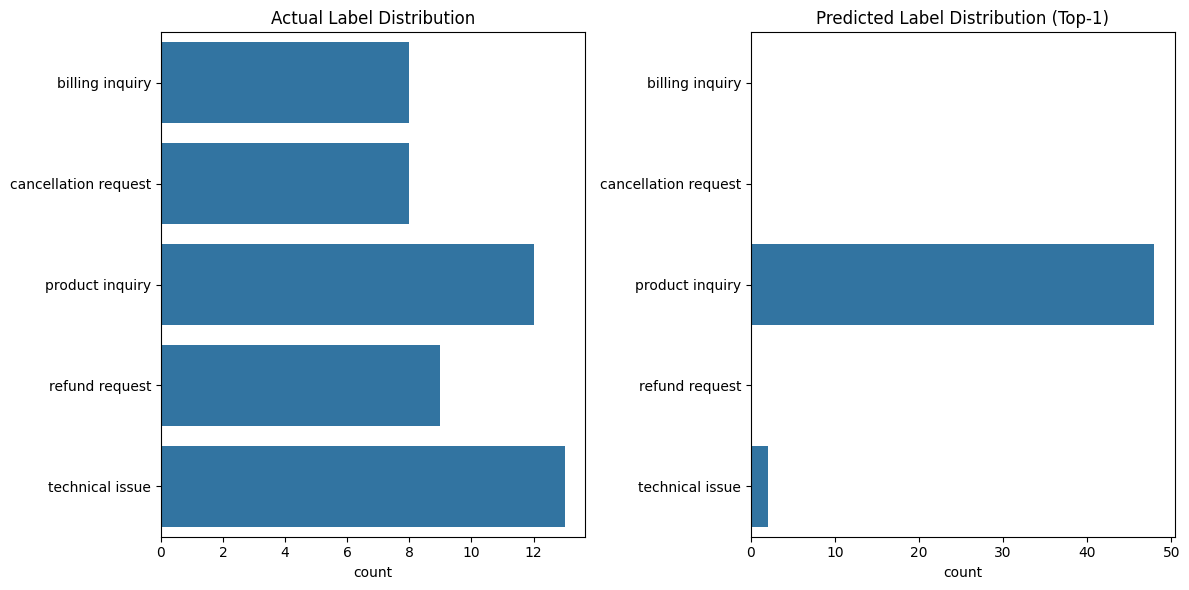

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for visualization
plt.figure(figsize=(12, 6))

# Compare distributions
plt.subplot(1, 2, 1)
sns.countplot(y=y_true, order=sorted(set(y_true)))
plt.title('Actual Label Distribution')

plt.subplot(1, 2, 2)
sns.countplot(y=y_pred_top1, order=sorted(set(y_true)))
plt.title('Predicted Label Distribution (Top-1)')

plt.tight_layout()
plt.show()